# **Nom : ILYASS OURAHOU**
**FIlière : ISI 2025-2026**

# Exploitation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df= pd .read_csv('gld_price_data.csv')
# Vue générale
print("***Info générale")
print(df.info())
print(" ")
print("***Info sur les lignes et colonnes")
print(df.shape)
print(" ")
print("***Info Statistiques")
print(df.describe()) # statistiques
print(" ")
print("***Info sur les valeurs manquantes")
print(df.isnull().sum()) # valeurs manquantes


***Info générale
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB
None
 
***Info sur les lignes et colonnes
(2290, 6)
 
***Info Statistiques
               SPX          GLD          USO          SLV      EUR/USD
count  2290.000000  2290.000000  2290.000000  2290.000000  2290.000000
mean   1654.315776   122.732875    31.842221    20.084997     1.283653
std     519.111540    23.283346    19.523517     7.092566     0.131547
min     676.530029    70.000000     7.960000     8.850000     1.039047
25%    1239.874969   109.725000    14.380000    15.570000     1.171313
50%    1551.434998

In [ ]:
print(df.head())

       Date          SPX        GLD        USO     SLV   EUR/USD
0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099


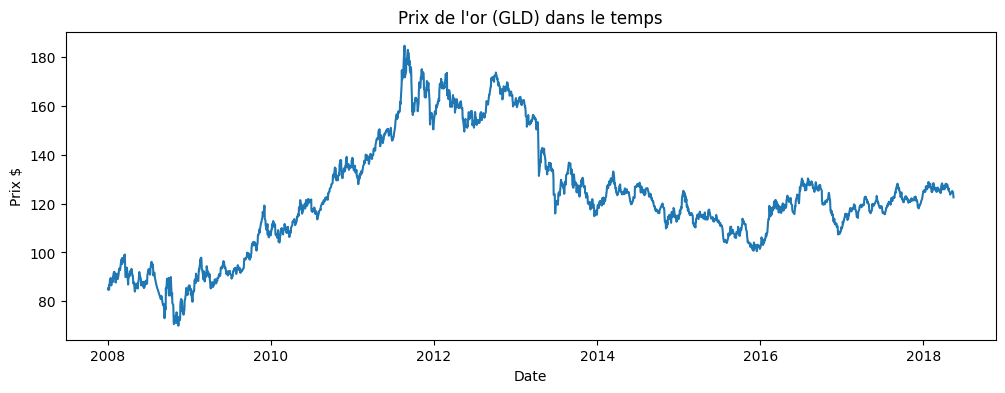

In [ ]:
# visualiser l'évolution du prix de l'or

df['Date']= pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['GLD'])
plt.title("Prix de l'or (GLD) dans le temps")
plt.xlabel('Date')
plt.ylabel('Prix $')
plt.show()

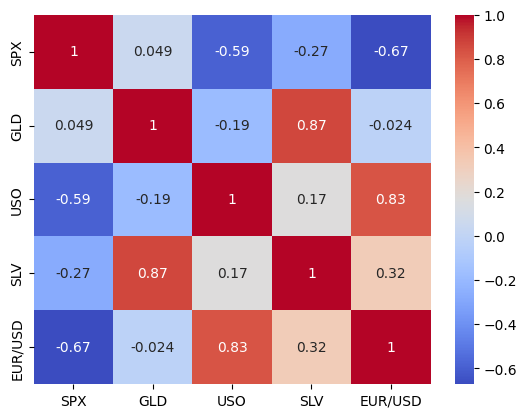

In [ ]:
# Corrélation entre Review et Global
correlation = df.drop('Date',axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#correlation de l'or

print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_6839/2460973210.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'])


<Axes: xlabel='GLD', ylabel='Density'>

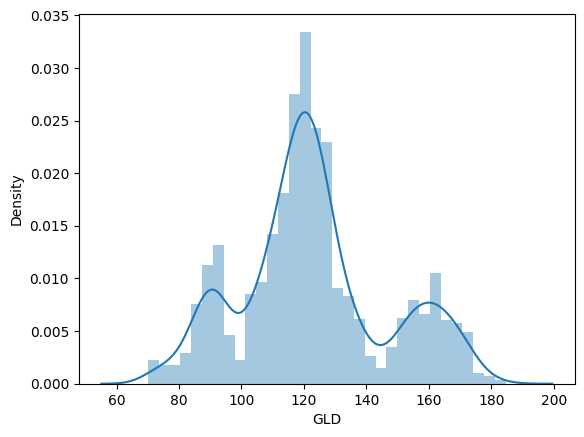

In [ ]:
# visualisation de la distrubution du prix d'or
sns.distplot(df['GLD'])

# Preprocessing

In [ ]:
df['GLD_lag1'] = df['GLD'].shift(1)          # prix de la veille
df['GLD_lag5'] = df['GLD'].shift(5)          # prix il y a 5 jours
df['GLD_ma7']  = df['GLD'].rolling(7).mean() # moyenne mobile 7 jours

# Supprimer les lignes NaN créées par shift/rolling
df = df.dropna().reset_index(drop=True)
print(f'Dataset après ajout des features lag : {df.shape}')
print(df[['Date', 'GLD', 'GLD_lag1', 'GLD_lag5', 'GLD_ma7']].head(10))

Dataset après ajout des features lag : (2278, 9)
        Date        GLD   GLD_lag1   GLD_lag5    GLD_ma7
0 2008-01-18  87.419998  86.500000  88.580002  87.854285
1 2008-01-22  88.169998  87.419998  89.540001  87.842856
2 2008-01-23  87.889999  88.169998  87.989998  87.744284
3 2008-01-24  90.080002  87.889999  86.699997  87.821427
4 2008-01-25  90.300003  90.080002  86.500000  88.151428
5 2008-01-28  91.750000  90.300003  87.419998  88.872857
6 2008-01-29  91.150002  91.750000  88.169998  89.537143
7 2008-01-30  92.059998  91.150002  87.889999  90.200000
8 2008-01-31  91.400002  92.059998  90.080002  90.661429
9 2008-02-01  89.349998  91.400002  90.300003  90.870001


## --Séparer les features (X) et cible (y)

In [ ]:
X = df[['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD_lag1', 'GLD_lag5', 'GLD_ma7']] # features
y = df['GLD']  # valeur a prédire
print('Features X :', X.shape)
print('Cible y    :', y.shape)

Features X : (2278, 7)
Cible y    : (2278,)


## --Splitting data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # ← pas de mélange !
)
print(f'Train : {len(X_train)} lignes ({df["Date"].iloc[0].date()} → {df["Date"].iloc[len(X_train)-1].date()})')
print(f'Test  : {len(X_test)} lignes  ({df["Date"].iloc[len(X_train)].date()} → {df["Date"].iloc[-1].date()})')

Train : 1822 lignes (2008-01-18 → 2016-04-18)
Test  : 456 lignes  (2016-04-19 → 2018-05-16)


## --Normalisation des features

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # apprend la moyenne/std sur train
X_test_scaled  = scaler.transform(X_test)        # applique la même transformation

# Model training

## Modèle 1 : Régression Linéaire

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)       #  X_train_scaled (pas X_train !)
y_pred_lr = model_lr.predict(X_test_scaled) #  X_test_scaled

## Modèle 2 : Random Forest

In [ ]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)

## Modèle 3 : Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train_scaled, y_train)
y_pred_gb = model_gb.predict(X_test_scaled)

# Evaluation

In [ ]:
import numpy as np
def evaluate(y_true, y_pred, nom):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'=== {nom} ===')
    print(f'MAE  : {mae:.2f}  → erreur moyenne en dollars')
    print(f'RMSE : {rmse:.2f}  → pénalise les grosses erreurs')
    print(f'R²   : {r2:.4f} → 1.0 = parfait, 0 = inutile, <0 = mauvais')
    print()

evaluate(y_test, y_pred_lr, 'Régression Linéaire')
evaluate(y_test, y_pred_rf, 'Random Forest')
evaluate(y_test, y_pred_gb, 'Gradient Boosting')

=== Régression Linéaire ===
MAE  : 0.67  → erreur moyenne en dollars
RMSE : 0.90  → pénalise les grosses erreurs
R²   : 0.9657 → 1.0 = parfait, 0 = inutile, <0 = mauvais

=== Random Forest ===
MAE  : 1.13  → erreur moyenne en dollars
RMSE : 1.43  → pénalise les grosses erreurs
R²   : 0.9130 → 1.0 = parfait, 0 = inutile, <0 = mauvais

=== Gradient Boosting ===
MAE  : 1.26  → erreur moyenne en dollars
RMSE : 1.60  → pénalise les grosses erreurs
R²   : 0.8904 → 1.0 = parfait, 0 = inutile, <0 = mauvais



# Visualisation des prédictions

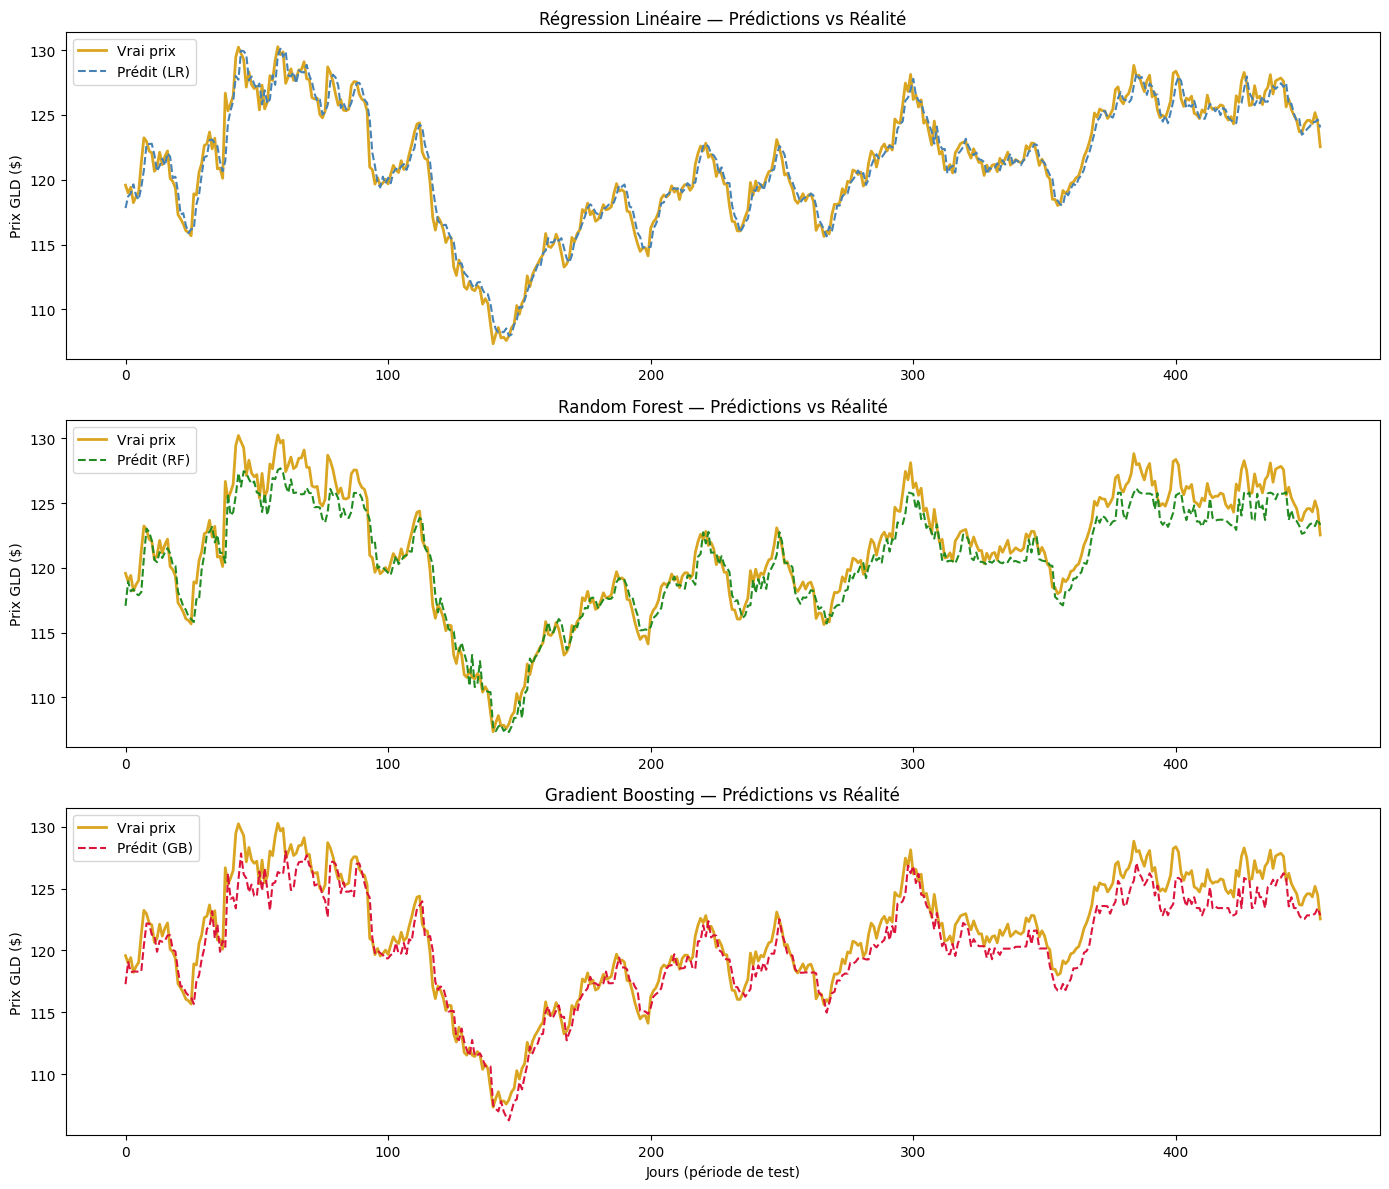

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Régression Linéaire ---
axes[0].plot(y_test.values, label='Vrai prix', color='goldenrod', linewidth=2)
axes[0].plot(y_pred_lr, label='Prédit (LR)', color='steelblue', linestyle='--', linewidth=1.5)
axes[0].set_title('Régression Linéaire — Prédictions vs Réalité')
axes[0].legend()
axes[0].set_ylabel('Prix GLD ($)')

# --- Random Forest ---
axes[1].plot(y_test.values, label='Vrai prix', color='goldenrod', linewidth=2)
axes[1].plot(y_pred_rf, label='Prédit (RF)', color='forestgreen', linestyle='--', linewidth=1.5)
axes[1].set_title('Random Forest — Prédictions vs Réalité')
axes[1].legend()
axes[1].set_ylabel('Prix GLD ($)')

# --- Gradient Boosting ---
axes[2].plot(y_test.values, label='Vrai prix', color='goldenrod', linewidth=2)
axes[2].plot(y_pred_gb, label='Prédit (GB)', color='crimson', linestyle='--', linewidth=1.5)
axes[2].set_title('Gradient Boosting — Prédictions vs Réalité')
axes[2].legend()
axes[2].set_ylabel('Prix GLD ($)')
axes[2].set_xlabel('Jours (période de test)')

plt.tight_layout()
plt.show()